# Начало работы с библиотекой Etna для прогнозирования временных рядов

Для решения задачи прогнозирования временных рядов (time series forecasting) разработано большое количество библиотек и фреймворков. Одним из популярных инструментов является библиотека Etna (от Т-Банка), которая позволяет быстро создавать прогностические статистические (и не только) модели, использующие структуры pandas.

# 1. Создание виртуального окружения

In [ ]:
import pandas as pd
import numpy as np

Главным минусом решения является сложность с ее встраиванием в готовые среды разработки (по типу anaconda и Google Colab): возникает конфликт версий, также библиотека медленно обновляется в pip и не поспевает за изменением версий Python.

Поэтому в проде пользоваться ей не рекомендуется, однако для быстрого моделирования она сойдет.

Чтобы импортировать Enta в Google Colab (и 99,9%, что в вашу локальную среду разработки на базе Jupyter), нужно сделать некоторые танцы с бубном и скачать библиотеку с гитхаба.

In [ ]:
pip install "etna@git+https://github.com/etna-team/etna.git@master"

  Cloning https://github.com/etna-team/etna.git (to revision master) to /tmp/pip-install-agt_fx4l/etna_06439b6408344ebfbd1fa51aee55c060
  Running command git clone --filter=blob:none --quiet https://github.com/etna-team/etna.git /tmp/pip-install-agt_fx4l/etna_06439b6408344ebfbd1fa51aee55c060
  Resolved https://github.com/etna-team/etna.git to commit c8e41911637c90e451e6f2bcc29f31d81bafab02
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.6/140.6 kB 14.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.6/14.6 MB 91.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 9.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.6/61.6 kB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 67.1 MB/s eta 0:00:

А потом только можно ее импортировать 😥 (предварительно перезагрузив виртуальное окружение).

In [ ]:
import etna

/usr/local/lib/python3.12/dist-packages/etna/settings.py:35: UserWarning: etna[torch] is not available, to install it, run `pip install etna[torch]`
  warnings.warn("etna[torch] is not available, to install it, run `pip install etna[torch]`")
/usr/local/lib/python3.12/dist-packages/etna/settings.py:64: UserWarning: etna[timesfm] is not available, to install it, run `pip install etna[timesfm]`
  warnings.warn("etna[timesfm] is not available, to install it, run `pip install etna[timesfm]`")
/usr/local/lib/python3.12/dist-packages/etna/settings.py:89: UserWarning: etna[classification] is not available, to install it, run `pip install etna[classification]`
  warnings.warn("etna[classification] is not available, to install it, run `pip install etna[classification]`")
/usr/local/lib/python3.12/dist-packages/etna/settings.py:98: UserWarning: etna[auto] is not available, to install it, run `pip install etna[auto]`
  warnings.warn("etna[auto] is not available, to install it, run `pip install et

# 2. Создание синтетического временного ряда

Для демонстрации работы библиотеки Etna создадим DataFrame с синтетическим временным рядом.

In [ ]:
num_entries = 200
interval_days = 1

In [ ]:
time_column = pd.date_range(start='2025-01-01', periods=num_entries, freq=f'{interval_days}D')

x = np.linspace(0, 4 * np.pi, num_entries)
sine_wave = 10 * np.sin(x)
trend = 0.5 * np.arange(num_entries)
errors = np.random.random(num_entries)

parameter_column = sine_wave + trend + errors + 50

df = pd.DataFrame({
    'Время': time_column,
    'Параметр': parameter_column
})

In [ ]:
df

,Время,Параметр
0,2025-01-01,50.069061
1,2025-01-02,51.519462
2,2025-01-03,52.412910
3,2025-01-04,53.644918
4,2025-01-05,55.381985
...,...,...
195,2025-07-15,145.440429
196,2025-07-16,146.884357
197,2025-07-17,147.281243
198,2025-07-18,148.514852


# 3. Создание основных объектов Etna

Для создания моделей необходимо

In [ ]:
df['timestamp'] = df['Время']
df['target'] = df['Параметр']

df.drop(columns=['Время', 'Параметр'], inplace=True)

In [ ]:
df

,timestamp,target
0,2025-01-01,50.069061
1,2025-01-02,51.519462
2,2025-01-03,52.412910
3,2025-01-04,53.644918
4,2025-01-05,55.381985
...,...,...
195,2025-07-15,145.440429
196,2025-07-16,146.884357
197,2025-07-17,147.281243
198,2025-07-18,148.514852


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   timestamp  200 non-null    datetime64[ns]
 1   target     200 non-null    float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 3.3 KB


In [ ]:
df['segment'] = 'main'
df

,timestamp,target,segment
0,2025-01-01,50.691272,main
1,2025-01-02,51.999521,main
2,2025-01-03,52.365870,main
3,2025-01-04,53.463335,main
4,2025-01-05,54.920862,main
...,...,...,...
195,2025-07-15,145.010121,main
196,2025-07-16,146.650820,main
197,2025-07-17,148.119799,main
198,2025-07-18,148.818836,main


In [ ]:
from etna.datasets import TSDataset


ts_dataset = TSDataset(df, 'D')
ts_dataset

segment,main
feature,target
timestamp,
2025-01-01,50.691272
2025-01-02,51.999521
2025-01-03,52.365870
2025-01-04,53.463335
2025-01-05,54.920862
...,...
2025-07-15,145.010121
2025-07-16,146.650820


In [ ]:
type(ts_dataset)

etna.datasets.tsdataset.TSDataset

In [ ]:
ts_dataset.info()

<class 'etna.datasets.TSDataset'>
num_segments: 1
num_exogs: 0
num_regressors: 0
num_known_future: 0
freq: D
end_timestamp: 2025-07-19 00:00:00
         start_timestamp  length  num_missing
segments                                     
main          2025-01-01     200            0


In [ ]:
ts_dataset.describe()

,start_timestamp,end_timestamp,length,num_missing,num_segments,num_exogs,num_regressors,num_known_future,freq
segments,,,,,,,,,
main,2025-01-01,2025-07-19,200,0,1,0,0,0,D


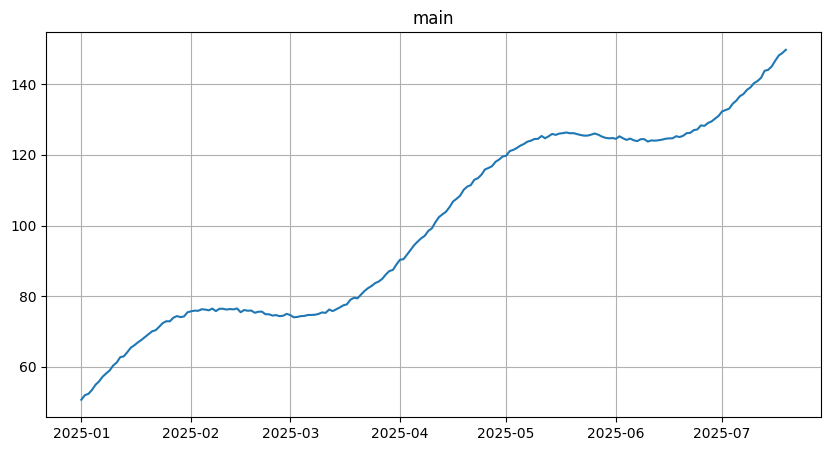

In [ ]:
ts_dataset.plot()